In [1]:
import os
os.chdir("..")

In [2]:
from src.data.cwru_load_data import cwru_read_mat, cwru_read_normal

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import resample_poly

In [3]:
fault_data = cwru_read_mat(r"D:\Capstone\data\raw\CWRU\12k_Drive_End_Bearing_Fault_Data")
norm_data = cwru_read_normal(r"D:\Capstone\data\raw\CWRU\Normal")

In [4]:
or_07_3 = fault_data['OR']['007']['@3'][0]['X144_DE_time'].squeeze()
or_07_6 = fault_data['OR']['007']['@6'][0]['X130_DE_time'].squeeze()
or_07_12 = fault_data['OR']['007']['@12'][0]['X156_DE_time'].squeeze()

or_14_0 = fault_data['OR']['014']['default'][0]['X197_DE_time'].squeeze()

or_21_3 = fault_data['OR']['021']['@3'][0]['X246_DE_time'].squeeze()
or_21_6 = fault_data['OR']['021']['@6'][0]['X234_DE_time'].squeeze()
or_21_12 = fault_data['OR']['021']['@12'][0]['X258_DE_time'].squeeze()

In [5]:
ir_07 = fault_data['IR']['007']['default'][0]['X105_DE_time'].squeeze()
ir_14 = fault_data['IR']['014']['default'][0]['X169_DE_time'].squeeze()
ir_21 = fault_data['IR']['021']['default'][0]['X209_DE_time'].squeeze()
ir_28 = fault_data['IR']['028']['default'][0]['X056_DE_time'].squeeze()

In [6]:
b_07 = fault_data['B']['007']['default'][0]['X118_DE_time'].squeeze()
b_14 = fault_data['B']['014']['default'][0]['X185_DE_time'].squeeze()
b_21 = fault_data['B']['021']['default'][0]['X222_DE_time'].squeeze()
b_28 = fault_data['B']['028']['default'][0]['X048_DE_time'].squeeze()

In [7]:
n_0 = norm_data['97_Normal_0']['X097_DE_time'].squeeze()
n_1 = norm_data['98_Normal_1']['X098_DE_time'].squeeze()
n_2 = norm_data['99_Normal_2']['X099_DE_time'].squeeze()
n_3 = norm_data['100_Normal_3']['X100_DE_time'].squeeze()

n_0 = resample_poly(n_0, up=1, down=4)
n_1 = resample_poly(n_1, up=1, down=4)
n_2 = resample_poly(n_2, up=1, down=4)
n_3 = resample_poly(n_3, up=1, down=4)

In [8]:
signal_list = [or_07_3[:2048], ir_07[:2048], b_07[:2048], n_0[:2048]]
label_list = ['Outer Race', 'Inner Race', 'Ball', 'Normal']

In [9]:
def plot_raw_signal(signal_list, label_list):
    fig, axes = plt.subplots(2, 2, figsize=(20, 10))

    for i, ax in enumerate(axes.flat):
        ax.plot(np.arange(len(signal_list[i])) / 12000,
                signal_list[i],
                linewidth=0.5)

        ax.set_title(label_list[i])
        ax.grid(True)

    fig.supxlabel("Time (s)")
    fig.supylabel("Amplitude")

    fig.suptitle("Time-domain", fontsize=16)

    plt.tight_layout()
    plt.show()

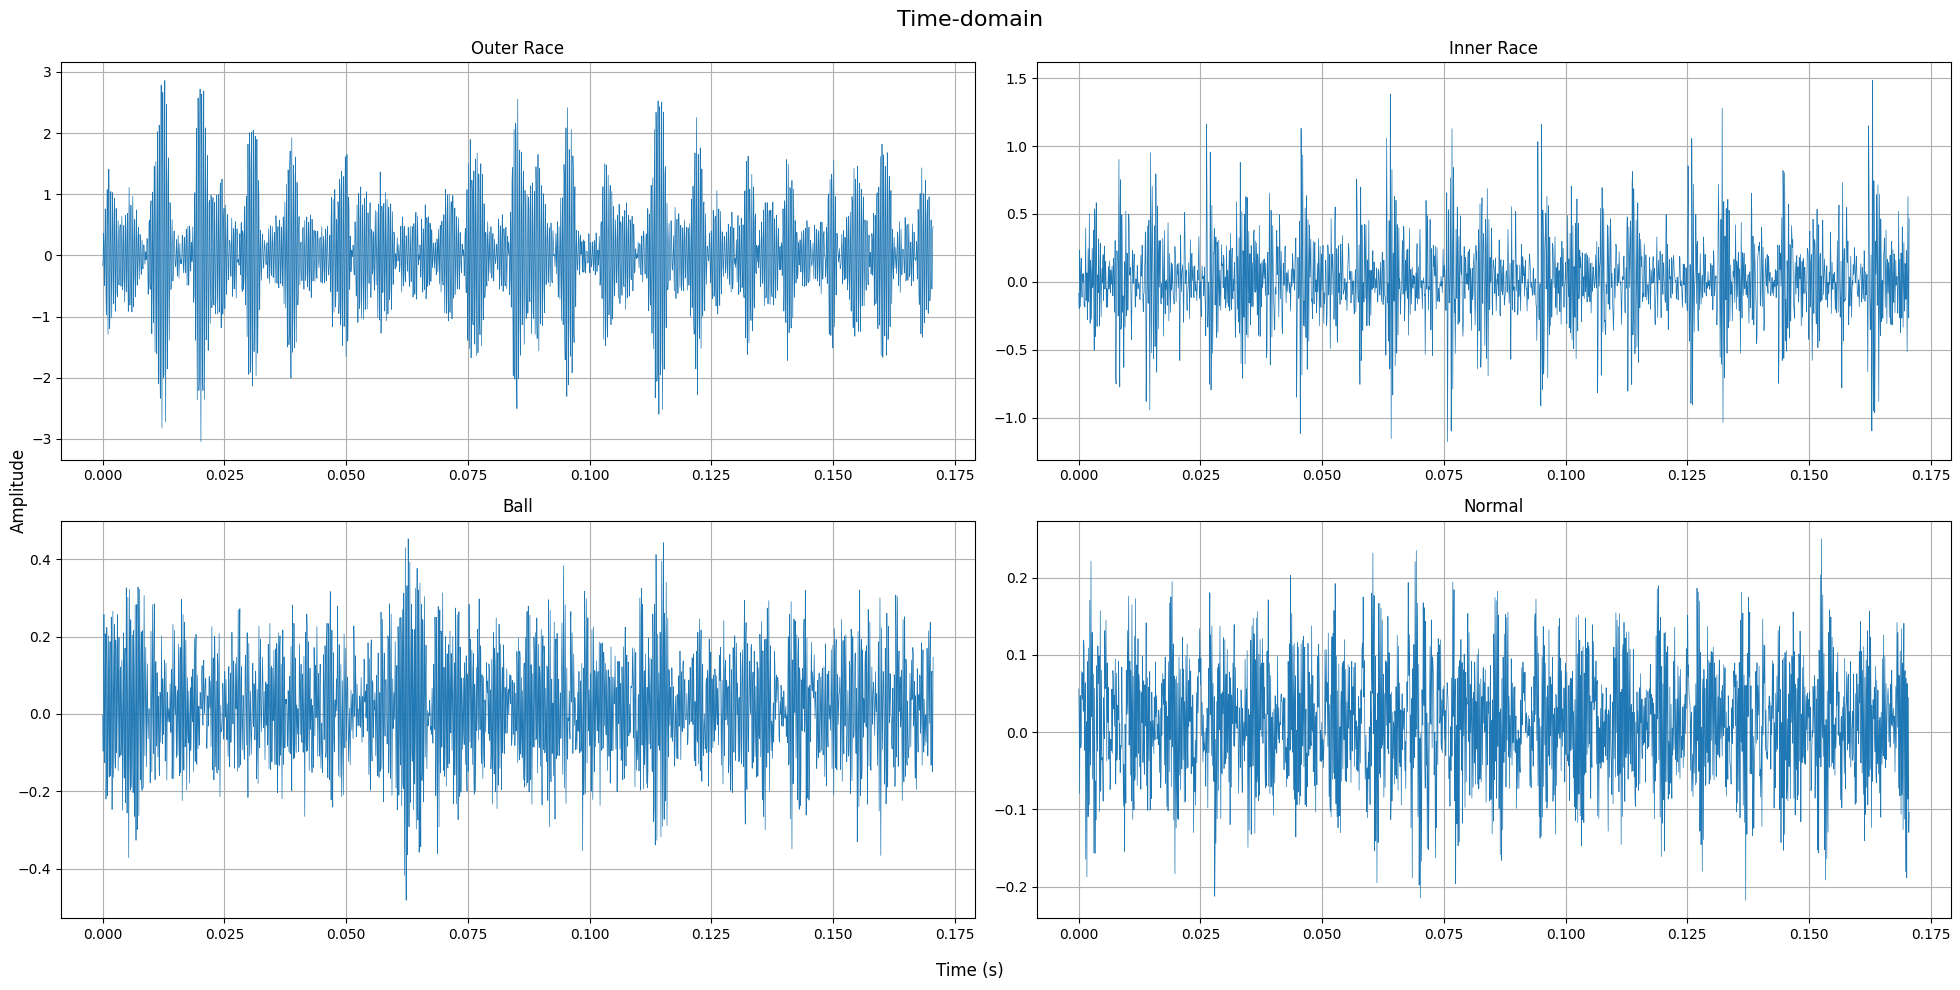

In [10]:
plot_raw_signal(signal_list, label_list)

In [11]:
def plot_fft(signal_list, label_list, fs):
    fig, axes = plt.subplots(2, 2, figsize=(20, 10))

    for i, ax in enumerate(axes.flat):
        fft_vals = np.fft.fft(signal_list[i])
        fft_freq = np.fft.fftfreq(len(signal_list[i]), 1/fs)
        positive_freq = fft_freq[:len(fft_freq)//2]
        amplitude = np.abs(fft_vals[:len(fft_vals)//2])

        ax.plot(positive_freq, amplitude)
        ax.set_title(label_list[i])
        ax.grid(True)

    fig.supxlabel("Frequency")
    fig.supylabel("Amplitude")

    fig.suptitle("Frequency-domain", fontsize=16)

    plt.tight_layout()
    plt.show()

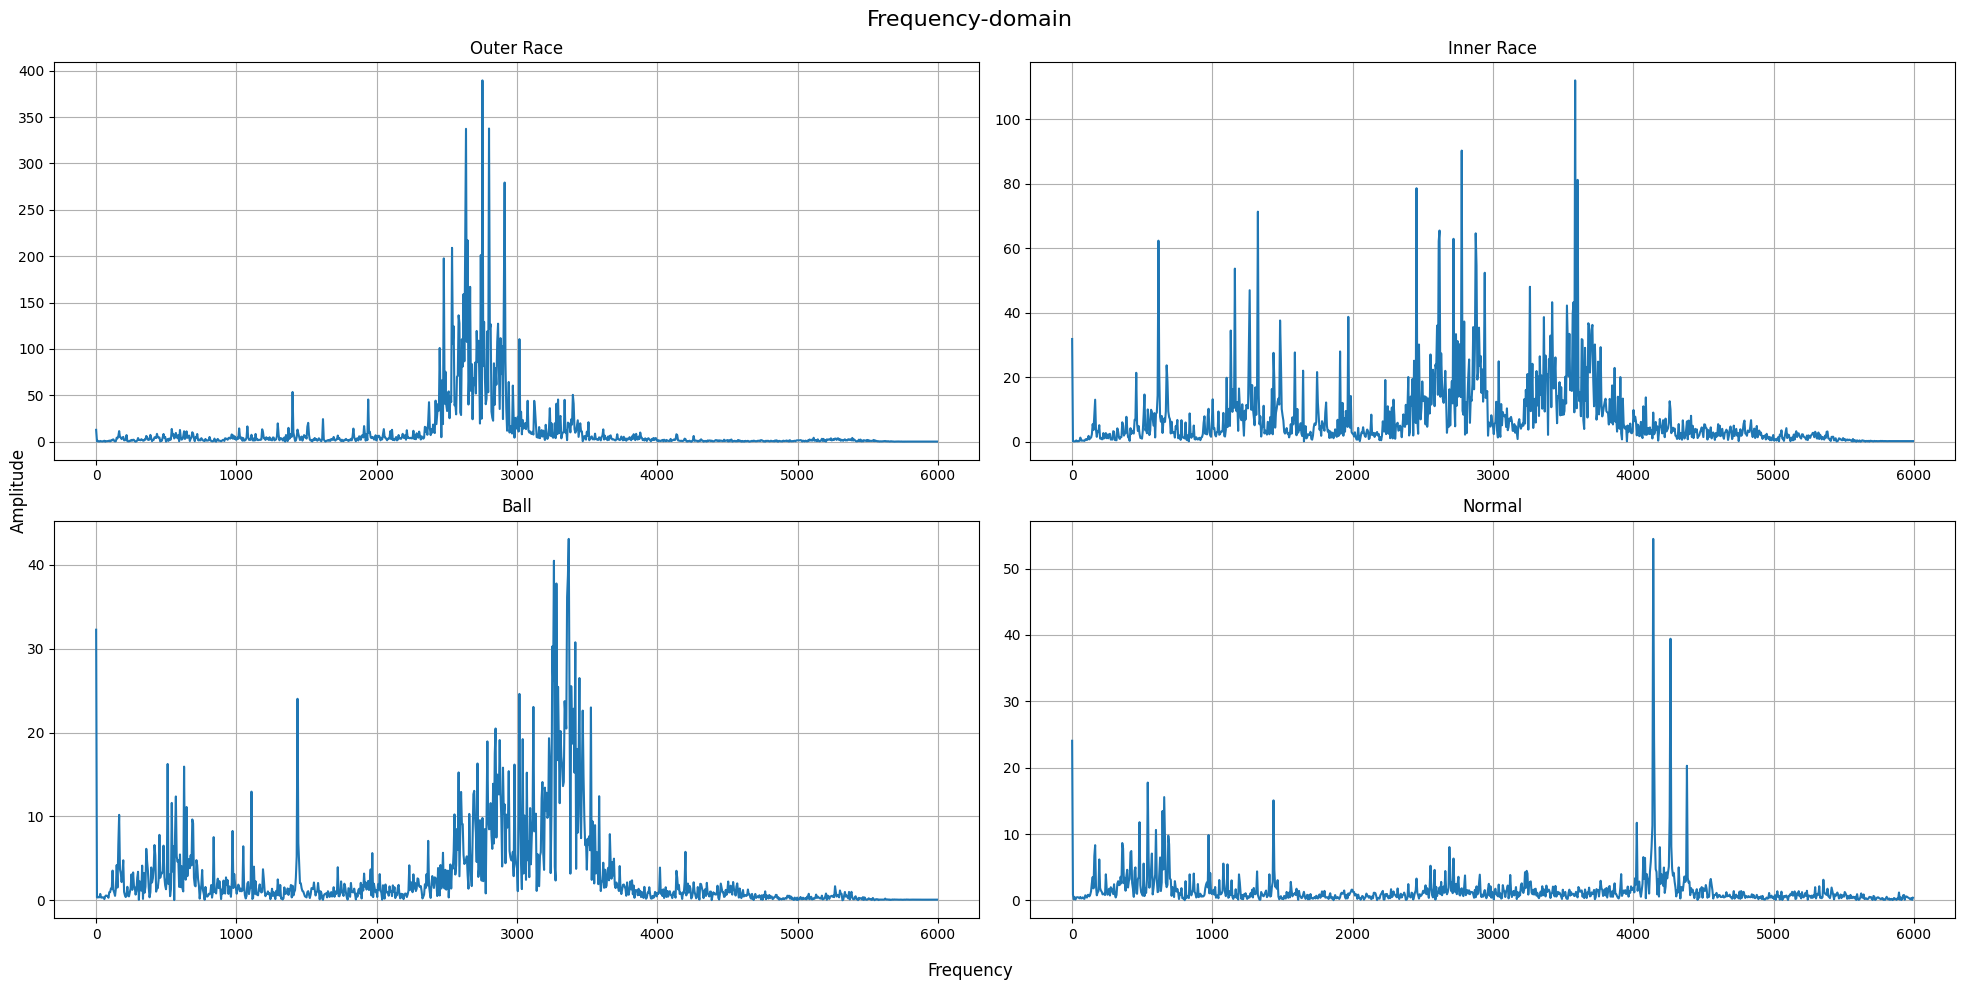

In [12]:
plot_fft(signal_list, label_list, 12000)

In [13]:
from scipy.signal import stft

In [ ]:
def plot_stft(signal_list, label_list, fs):
    fig, axes = plt.subplots(2, 2, figsize=(20, 10))

    for i, ax in enumerate(axes.flat):
        signal = (signal_list[i] - np.mean(signal_list[i])) / (np.std(signal_list[i]) + 1e-8)

        f, t, Zxx = stft(signal, fs=fs, window="hann", nperseg=256, noverlap=128)
        spectrogram = np.log1p(np.abs(Zxx))

        ax.set_title(label_list[i])

        im = ax.pcolormesh(t, f, spectrogram, shading='gouraud')
        ax.set_title(label_list[i])
        ax.set_ylim(0, fs/2)

        fig.colorbar(im, ax=ax)

    fig.supxlabel("Time (s)")
    fig.supylabel("Frequency (Hz)")

    fig.suptitle("Frequency-domain", fontsize=16)

    plt.tight_layout()
    plt.show()

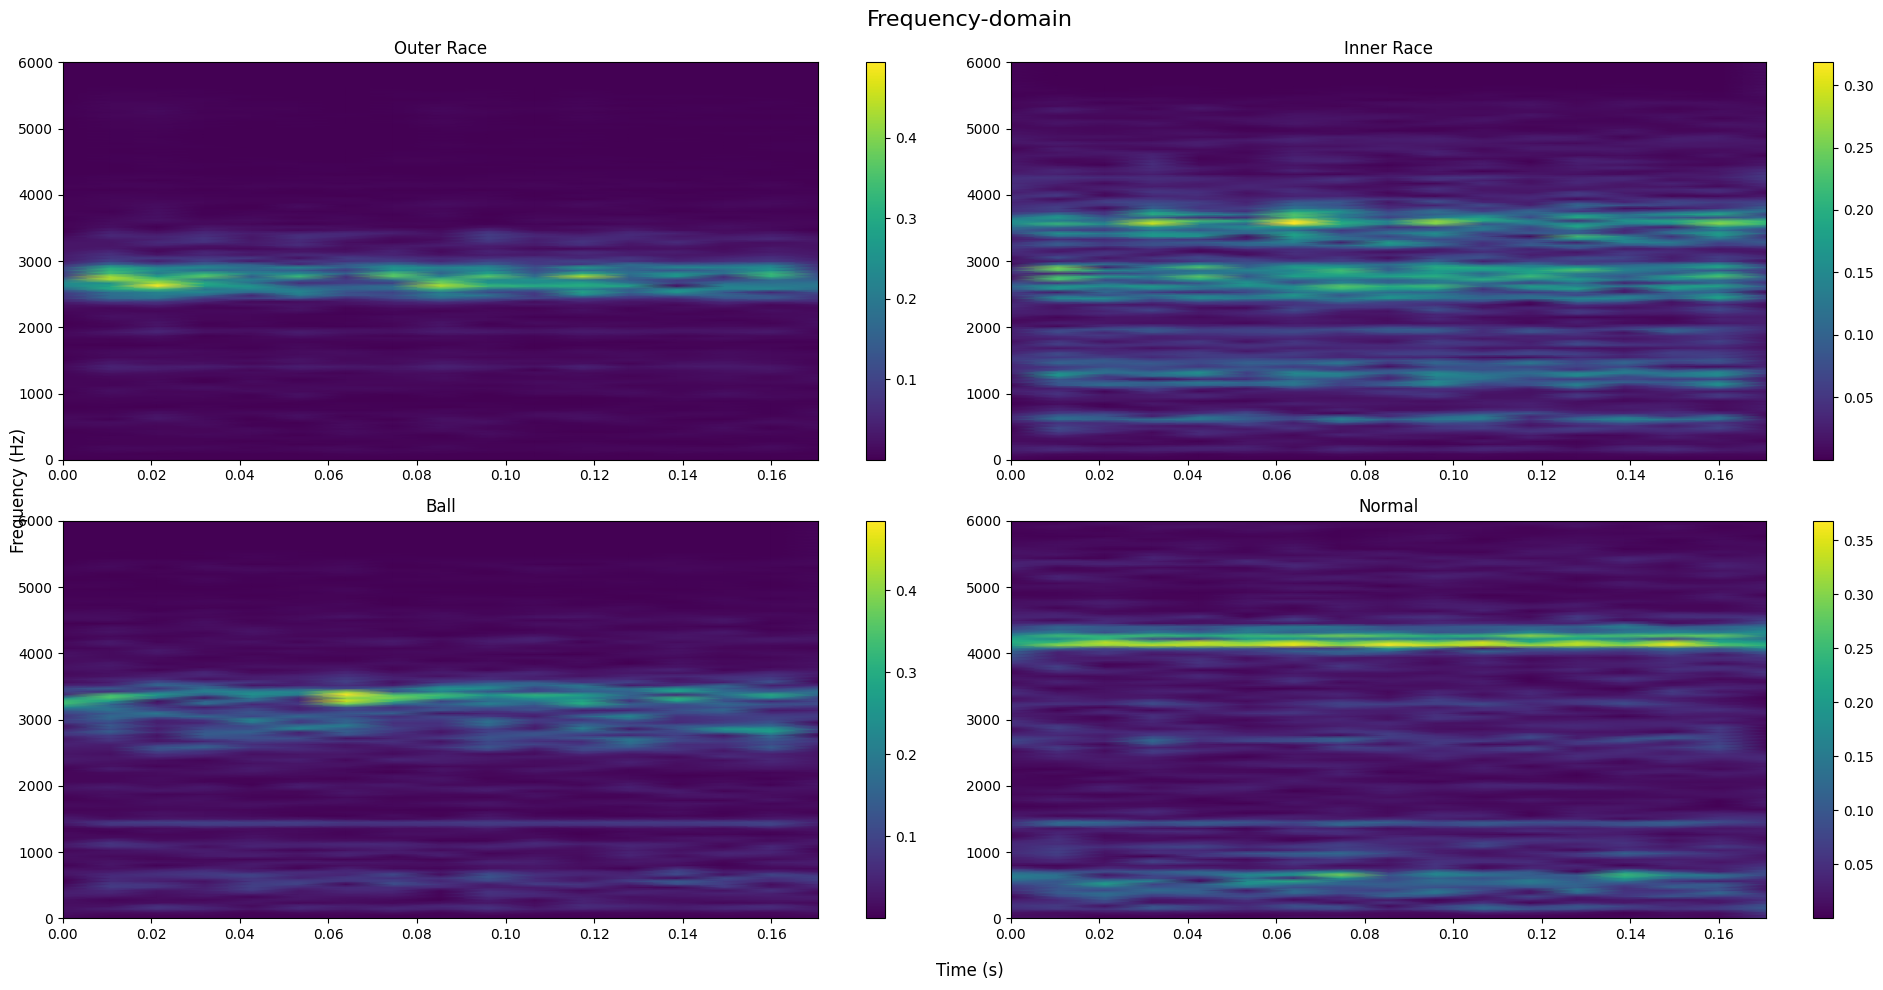

In [27]:
plot_stft(signal_list, label_list, 12000)

In [28]:
import pywt

In [33]:
def plot_cwt(signal_list, label_list, fs):
    fig, axes = plt.subplots(2, 2, figsize=(20, 10))

    for i, ax in enumerate(axes.flat):
        signal = (signal_list[i] - np.mean(signal_list[i])) / (np.std(signal_list[i]) + 1e-8)

        scales = np.arange(1, 128 + 1)
        coeffs, freqs = pywt.cwt(signal, scales, 'morl', sampling_period=1/fs)
        scalogram = np.log1p(np.abs(coeffs))

        time = np.arange(len(signal)) / fs

        ax.set_title(label_list[i])

        im = ax.pcolormesh(time, freqs, scalogram, shading='gouraud')
        ax.set_title(label_list[i])
        ax.set_ylim(0, fs/2)

        fig.colorbar(im, ax=ax)

    fig.supxlabel("Time (s)")
    fig.supylabel("Frequency (Hz)")

    fig.suptitle("Frequency-domain", fontsize=16)

    plt.tight_layout()
    plt.show()

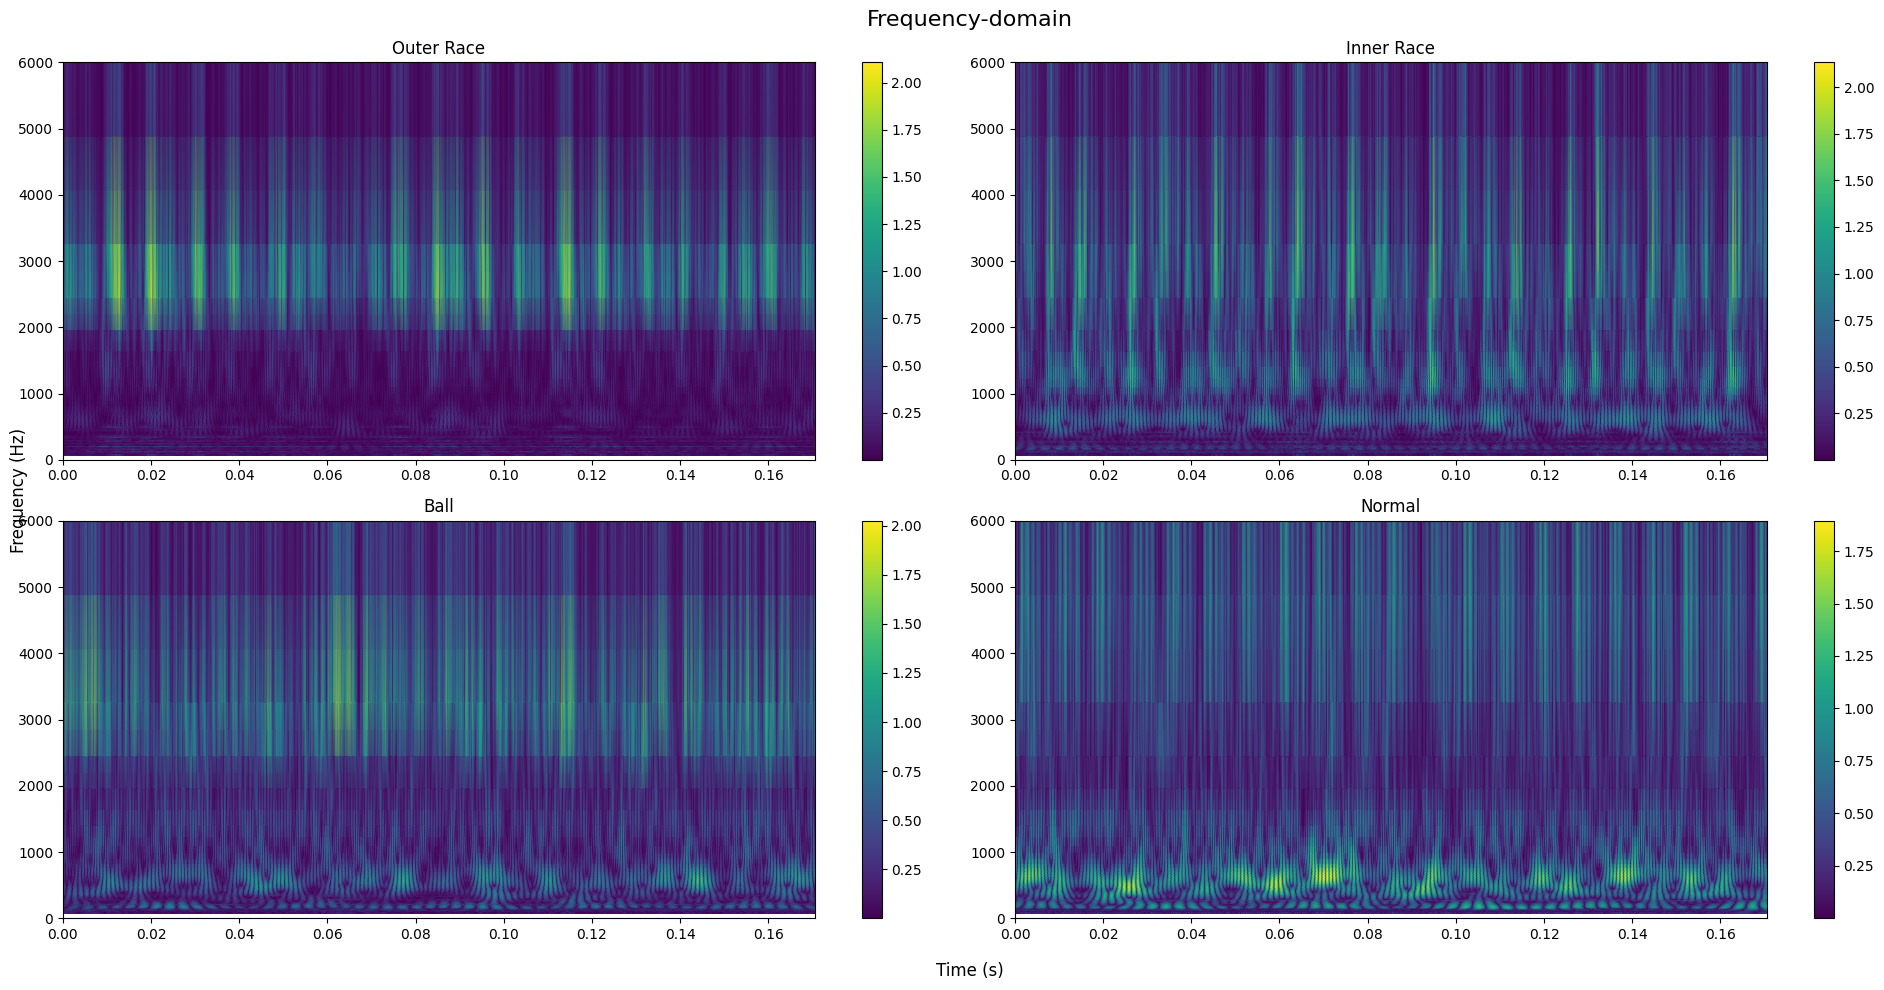

In [34]:
plot_cwt(signal_list, label_list, 12000)

In [35]:
from src.features.cwt import cwt2scalogram
from src.features.stft import stft2spectrogram

In [51]:
cwt_images = [cwt2scalogram(signal) for signal in signal_list]
stft_images = [stft2spectrogram(signal) for signal in signal_list]

In [59]:
def plot_images(images, label_list):
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    for i, ax in enumerate(axes.flat):
        img = images[i].transpose(1, 2, 0)

        ax.imshow(img, aspect='auto')
        ax.set_title(label_list[i])
        ax.axis("off")

    fig.suptitle("Spectrogram", fontsize=16)

    plt.tight_layout()
    plt.show()

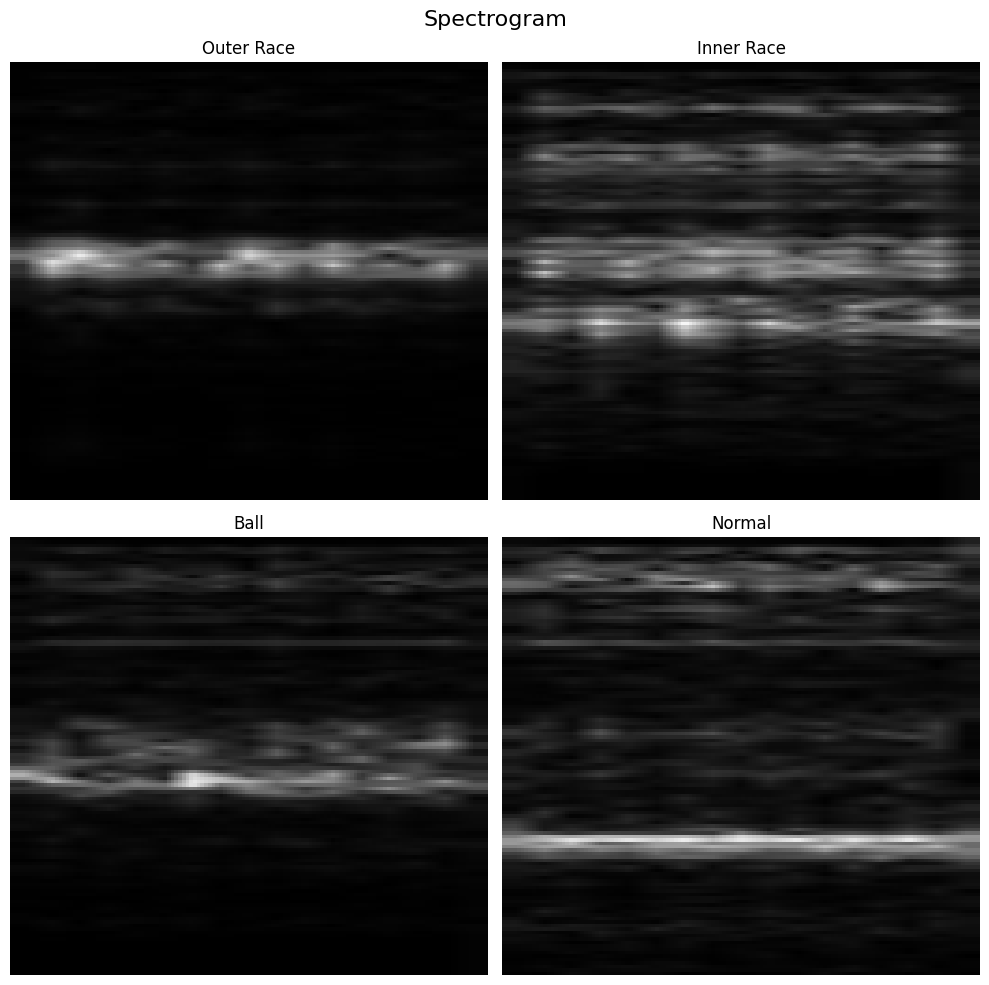

In [60]:
plot_images(stft_images, label_list)

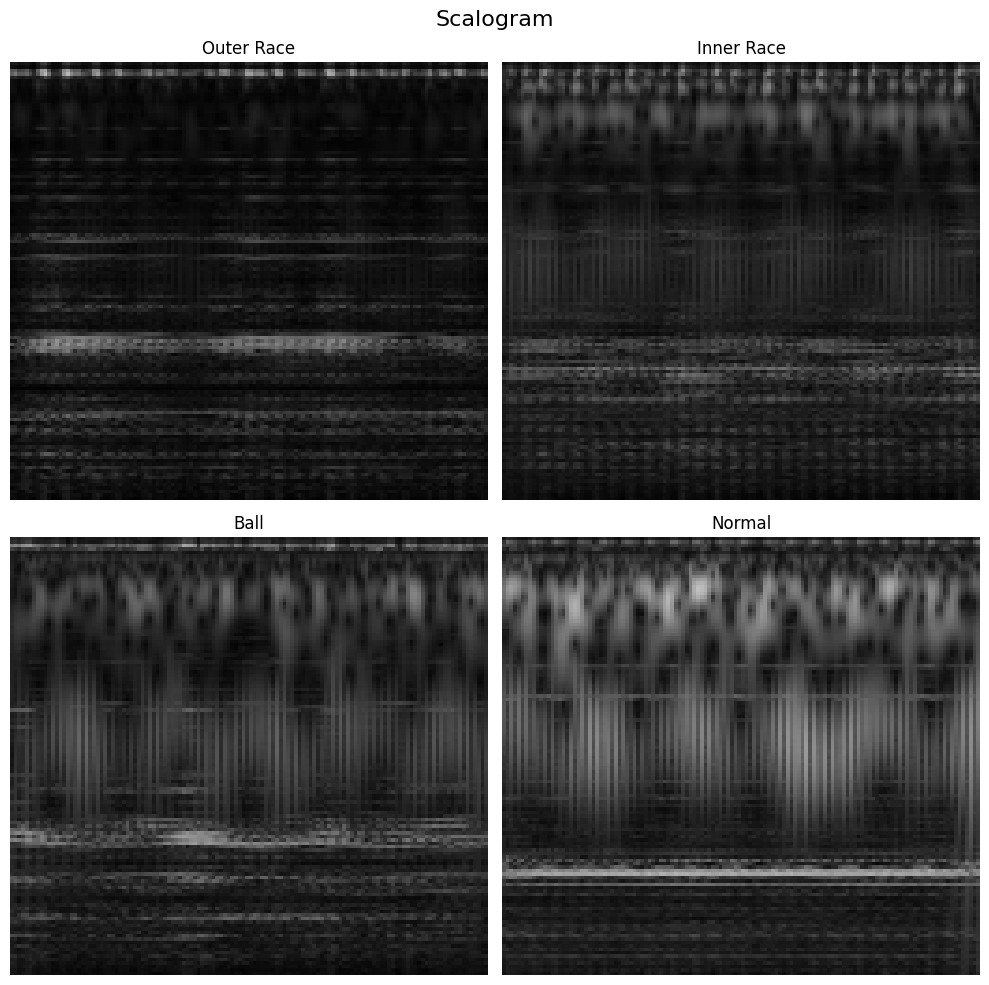

In [58]:
plot_images(cwt_images, label_list)